In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_data=pd.read_csv("../data/clean_data/datacocleaned.csv")
df_token=pd.read_csv("../data/clean_data/tokenizedLogo.csv")

In [3]:
df_data.isnull().mean()*100

Unnamed: 0                         0.000000
type                               0.000000
days_for_shipping_(real)           0.000000
days_for_shipment_(scheduled)      0.000000
benefit_per_order                  0.000000
sales_per_customer                 0.000000
delivery_status                    0.000000
late_delivery_risk                 0.000000
category_id                        0.000000
category_name                      0.000000
customer_city                      0.000000
customer_country                   0.000000
customer_email                     0.000000
customer_fname                     0.000000
customer_id                        0.000000
customer_lname                     0.000000
customer_password                  0.000000
customer_segment                   0.000000
customer_state                     0.000000
customer_street                    0.000000
customer_zipcode                   0.001662
department_id                      0.000000
department_name                 

In [4]:
df_data.duplicated().sum()

np.int64(0)

In [5]:
df_token.isnull().mean()*100

Unnamed: 0    0.0
product       0.0
category      0.0
date          0.0
month         0.0
hour          0.0
department    0.0
ip            0.0
url           0.0
dtype: float64

In [6]:
df_token.duplicated().sum()

np.int64(0)

# EDA START HERE

In [7]:
df_data.columns

Index(['Unnamed: 0', 'type', 'days_for_shipping_(real)',
       'days_for_shipment_(scheduled)', 'benefit_per_order',
       'sales_per_customer', 'delivery_status', 'late_delivery_risk',
       'category_id', 'category_name', 'customer_city', 'customer_country',
       'customer_email', 'customer_fname', 'customer_id', 'customer_lname',
       'customer_password', 'customer_segment', 'customer_state',
       'customer_street', 'customer_zipcode', 'department_id',
       'department_name', 'latitude', 'longitude', 'market', 'order_city',
       'order_country', 'order_customer_id', 'order_date_(dateorders)',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'order_zipcode', 'product_card_id',
       'product_category_id

In [8]:
df_token.columns

Index(['Unnamed: 0', 'product', 'category', 'date', 'month', 'hour',
       'department', 'ip', 'url'],
      dtype='str')

# 1. Univariate Analysis (DataCO)

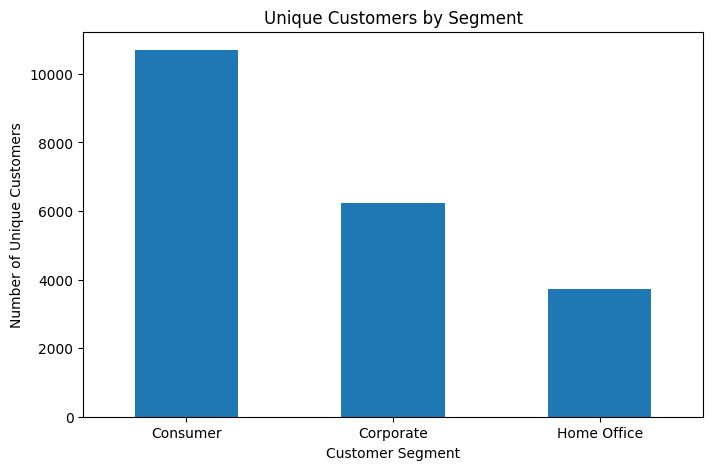

In [9]:
# 1. What is the distribution of customer across segemnts?
(
    df_data.groupby("customer_segment")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .plot(kind="bar", figsize=(8,5))
)

plt.title("Unique Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Unique Customers")
plt.xticks(rotation=0)
plt.show()

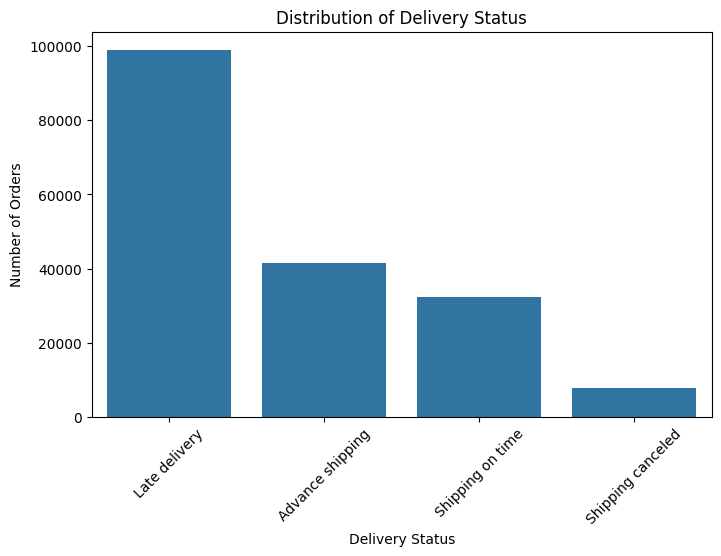

In [10]:
# 2. How many orders are delivered late, on time, shipped, etc.?
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_data,
    x="delivery_status",
    order=df_data["delivery_status"].value_counts().index
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

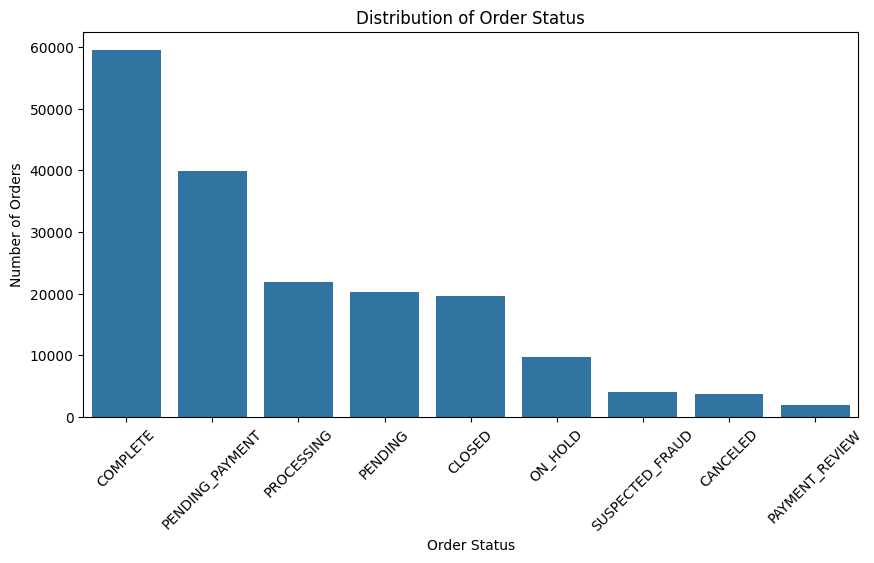

In [11]:
# 3. Which order statuses occur most frequently?
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_data,
    x="order_status",
    order=df_data["order_status"].value_counts().index
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

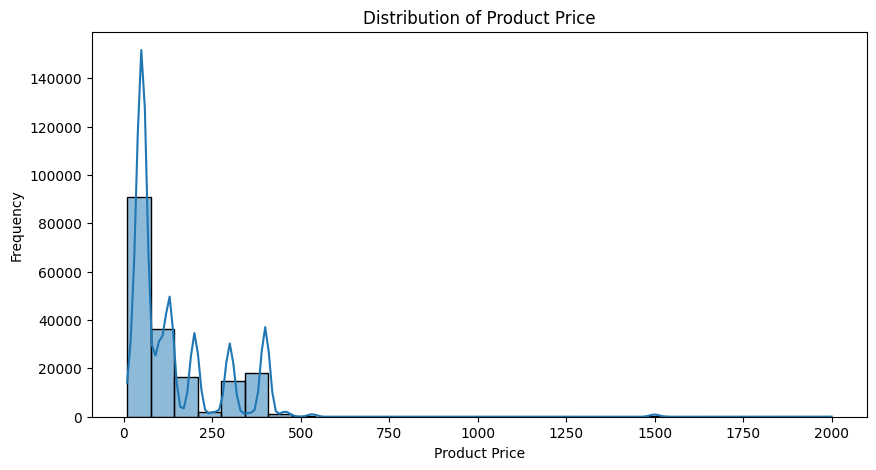

In [12]:
# 4. Are most products low-priced, medium-priced, or expensive?
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_data,
    x="product_price",
    bins=30,
    kde=True
)

plt.title("Distribution of Product Price")
plt.xlabel("Product Price")
plt.ylabel("Frequency")

plt.show()

# 2. Bivariate Analysis

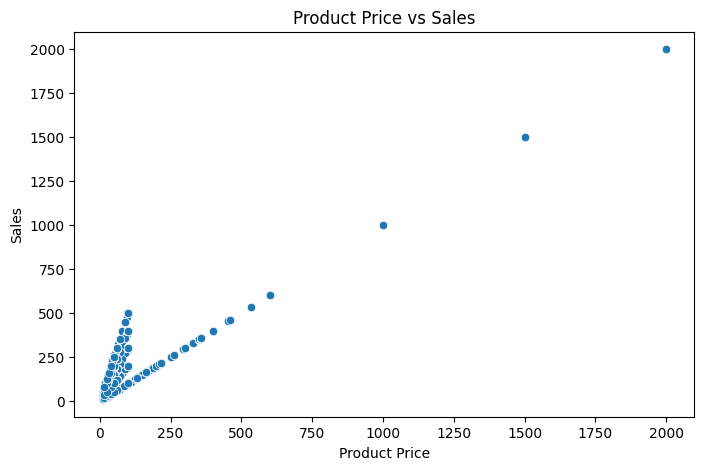

In [13]:
# Does increasing product price lead to higher sales?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_data,
    x="product_price",
    y="sales"
)

plt.title("Product Price vs Sales")
plt.xlabel("Product Price")
plt.ylabel("Sales")

plt.show()

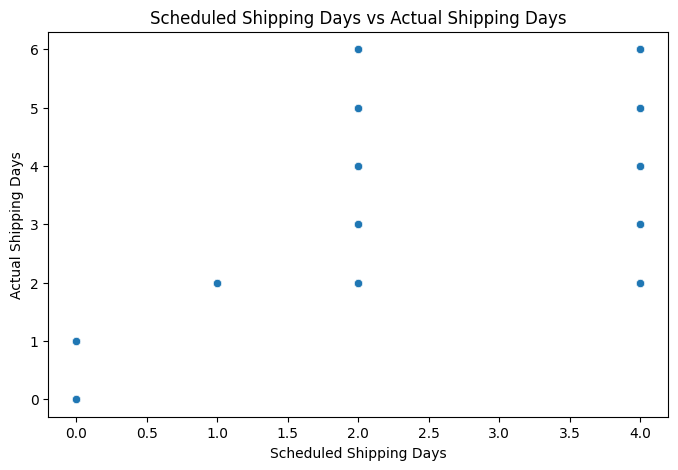

In [14]:
# 2. How closely do actual shipping days match scheduled shipping days?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_data,
    x="days_for_shipment_(scheduled)",
    y="days_for_shipping_(real)"
)

plt.title("Scheduled Shipping Days vs Actual Shipping Days")
plt.xlabel("Scheduled Shipping Days")
plt.ylabel("Actual Shipping Days")

plt.show()

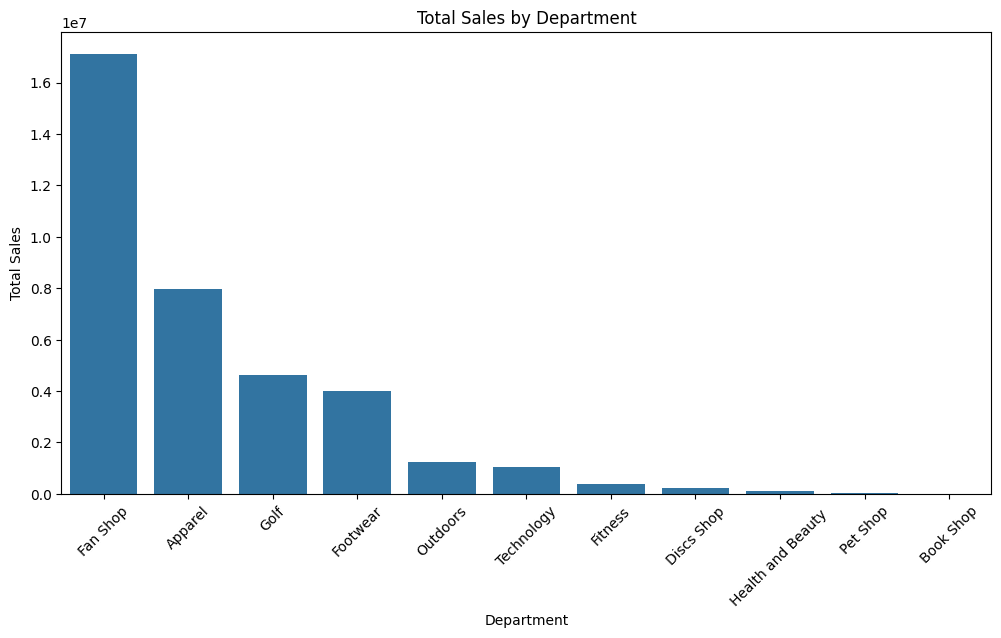

In [15]:
# 3. Which departments generate the highest total sales?
sales_by_department = (
    df_data.groupby("department_name")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=sales_by_department.index,
    y=sales_by_department.values
)

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

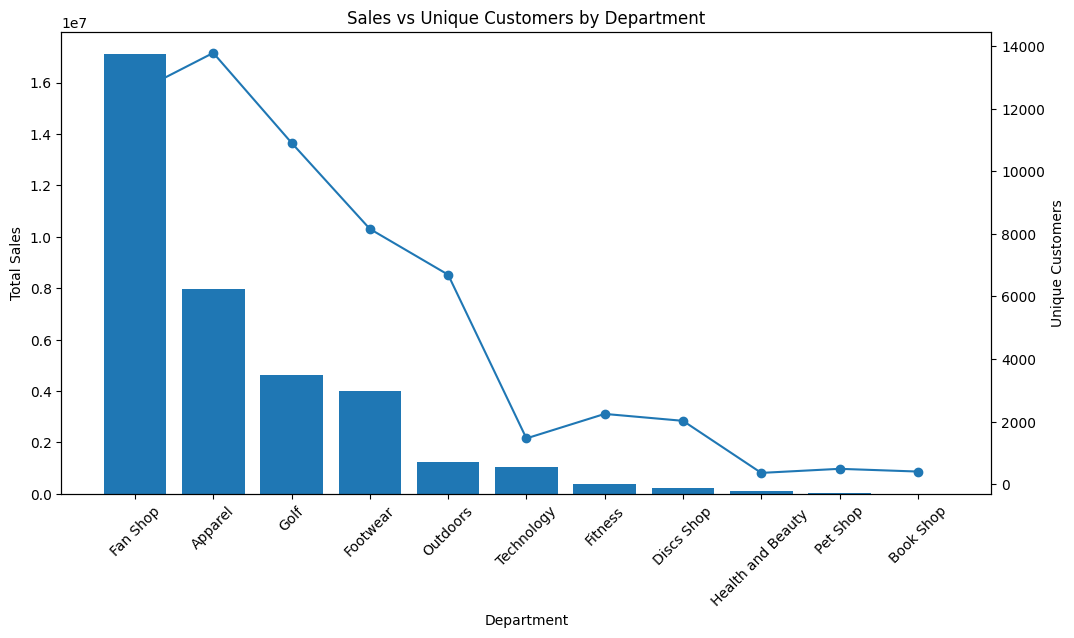

In [16]:
# 4. Do departments with more customers also generate more sales?
dept_analysis = (
    df_data.groupby("department_name")
    .agg(
        Total_Sales=("sales", "sum"),
        Unique_Customers=("customer_id", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    dept_analysis.index,
    dept_analysis["Total_Sales"]
)

ax1.set_ylabel("Total Sales")
ax1.set_xlabel("Department")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    dept_analysis.index,
    dept_analysis["Unique_Customers"],
    marker="o"
)

ax2.set_ylabel("Unique Customers")

plt.title("Sales vs Unique Customers by Department")

plt.show()

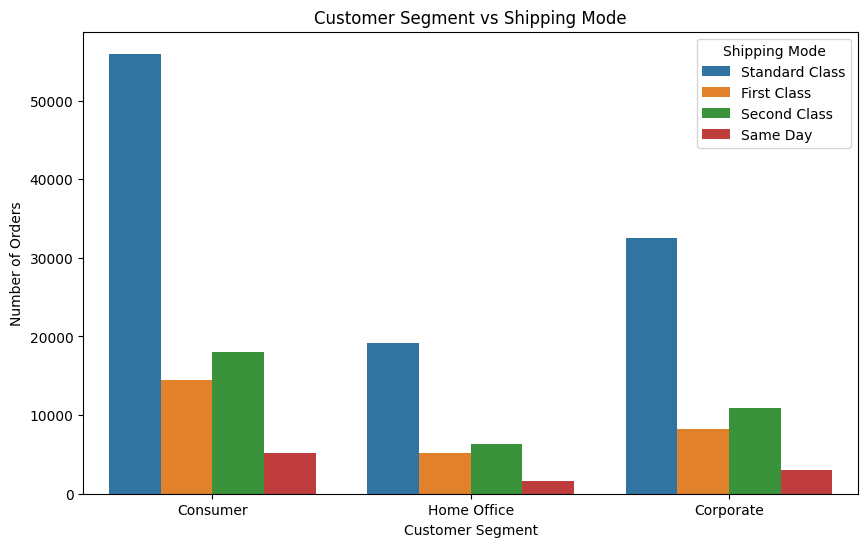

In [17]:
# 5. hich shipping modes are preferred by different customer segments?
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_data,
    x="customer_segment",
    hue="shipping_mode"
)

plt.title("Customer Segment vs Shipping Mode")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")
plt.legend(title="Shipping Mode")

plt.show()

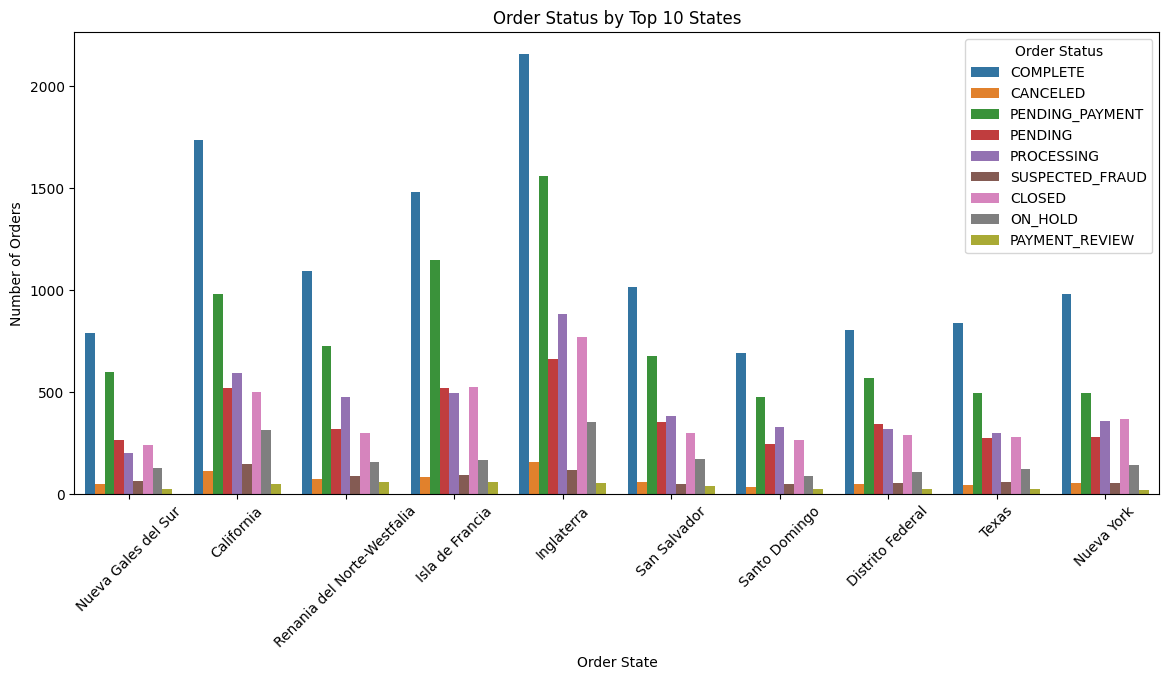

In [18]:
# 6. Do certain states have higher cancellations, delays, or fraud-related orders?

top_states = df_data["order_state"].value_counts().head(10).index

filtered_df = df_data[df_data["order_state"].isin(top_states)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=filtered_df,
    x="order_state",
    hue="order_status"
)

plt.title("Order Status by Top 10 States")
plt.xlabel("Order State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Order Status")

plt.show()

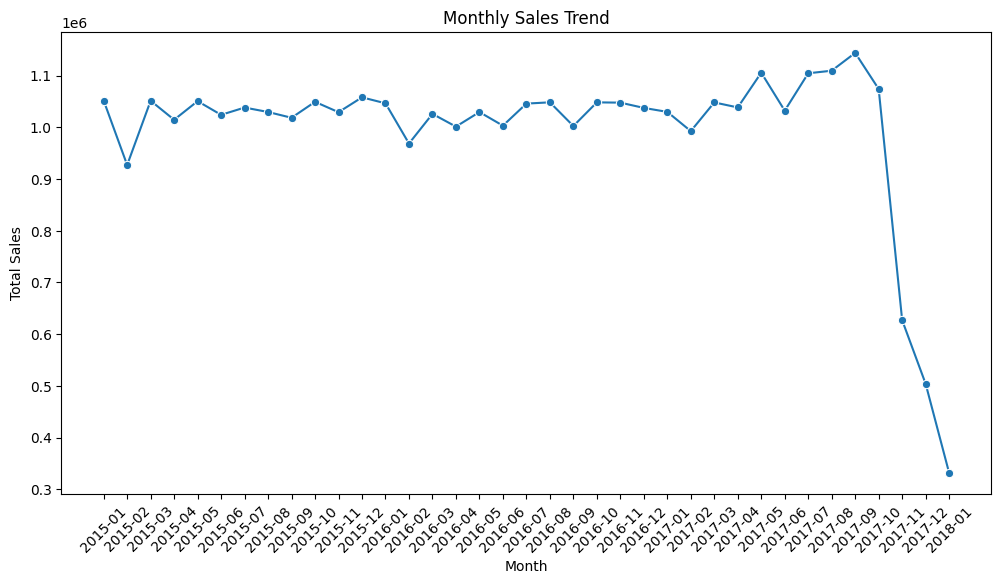

In [34]:
# 7. Are sales improving over time, and when are the peak demand periods?
# Convert to datetime
df_data["order_date_(dateorders)"] = pd.to_datetime(
    df_data["order_date_(dateorders)"]
)

# Monthly sales trend
monthly_sales = (
    df_data
    .groupby(df_data["order_date_(dateorders)"].dt.to_period("M"))["sales"]
    .sum()
    .reset_index()
)

monthly_sales["order_date_(dateorders)"] = (
    monthly_sales["order_date_(dateorders)"].astype(str)
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="order_date_(dateorders)",
    y="sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

# 3. Multivariate Analysis

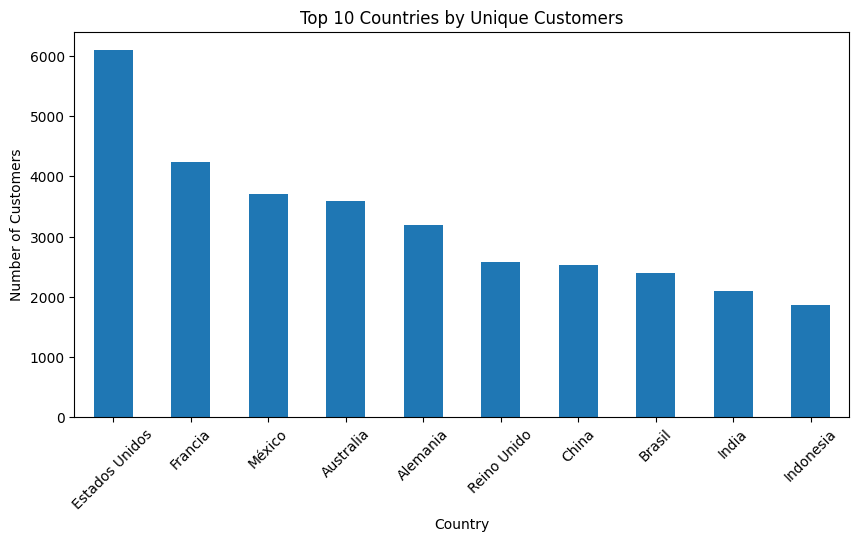

In [19]:
# 1. Which countries have the most customers?

country_customers = (
    df_data.groupby("order_country")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

country_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Unique Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

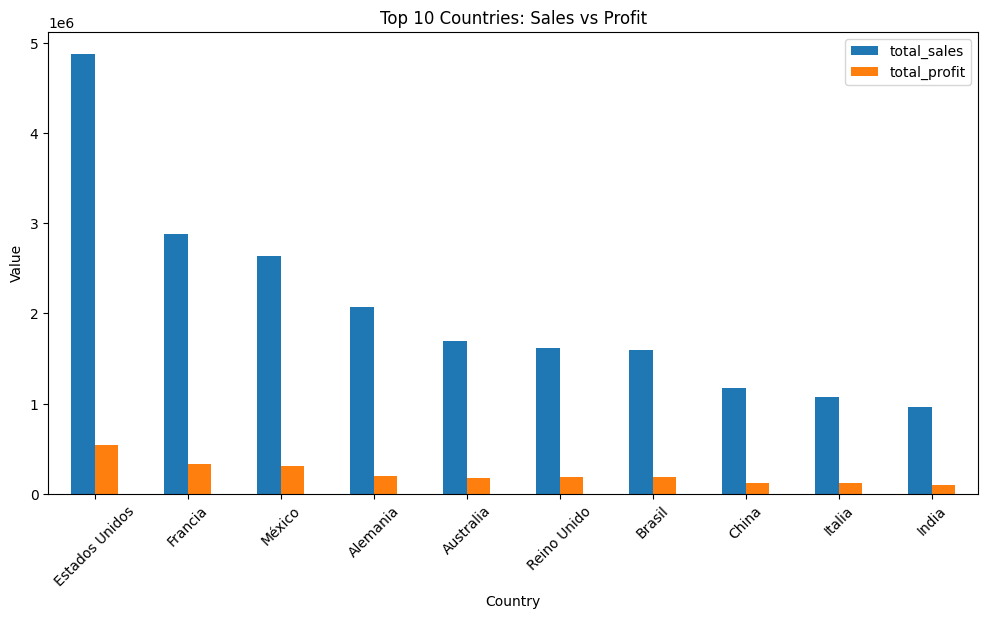

In [20]:
# 2. Which countries generate the most sales and profit?
country_sales_profit = (
    df_data.groupby("order_country")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("order_profit_per_order", "sum")
    )
    .sort_values("total_sales", ascending=False)
    .head(10)
)

country_sales_profit.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Countries: Sales vs Profit")
plt.xlabel("Country")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show() 

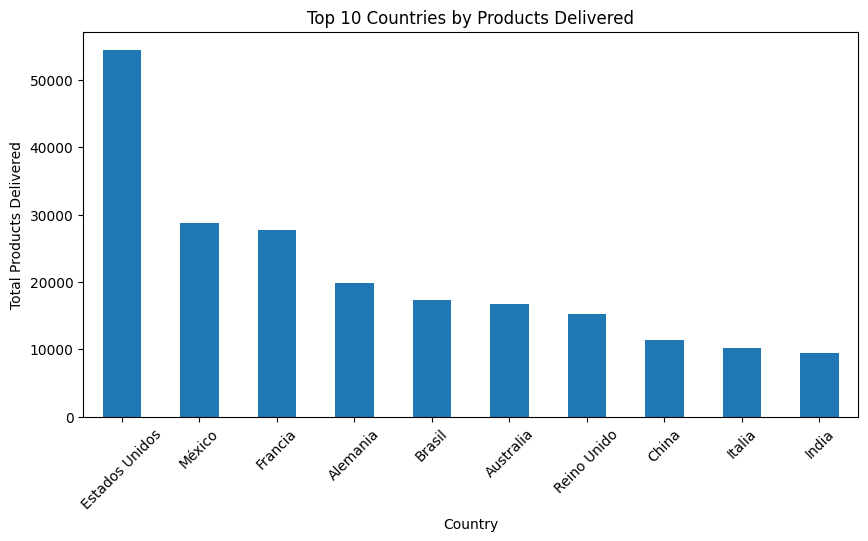

In [21]:
# 3. Which countries receive the most deliveries?
country_orders = (
    df_data.groupby("order_country")["order_item_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_orders.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Products Delivered")
plt.xlabel("Country")
plt.ylabel("Total Products Delivered")
plt.xticks(rotation=45)
plt.show()

                 Total_Sales  Total_Profit
discount_group                            
Discounted      3.474237e+07  3.699491e+06
Non-Discounted  2.042369e+06  2.674124e+05


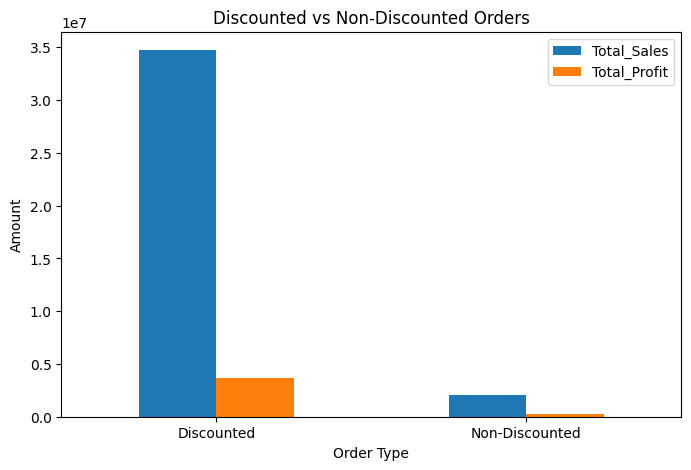

discount_group
Discounted        21.699037
Non-Discounted    26.666574
Name: order_profit_per_order, dtype: float64

In [24]:
# 4. Do discounted products generate more profit than non-discounted products?
discount_analysis = (
    df_data.assign(
        discount_group=df_data["order_item_discount"].gt(0)
        .map({True: "Discounted", False: "Non-Discounted"})
    )
    .groupby("discount_group")
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("order_profit_per_order", "sum")
    )
)

print(discount_analysis)


discount_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Discounted vs Non-Discounted Orders")
plt.xlabel("Order Type")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

df_data.assign(
    discount_group=df_data["order_item_discount"].gt(0)
    .map({True: "Discounted", False: "Non-Discounted"})
).groupby("discount_group")["order_profit_per_order"].mean()

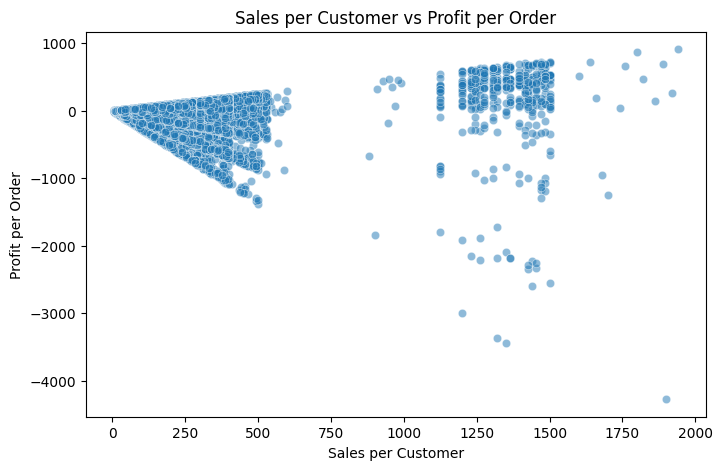

In [25]:
# 5. Do orders with higher sales per customer generate higher profit per order?
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_data,
    x="sales_per_customer",
    y="order_profit_per_order",
    alpha=0.5
)

plt.title("Sales per Customer vs Profit per Order")
plt.xlabel("Sales per Customer")
plt.ylabel("Profit per Order")

plt.show()

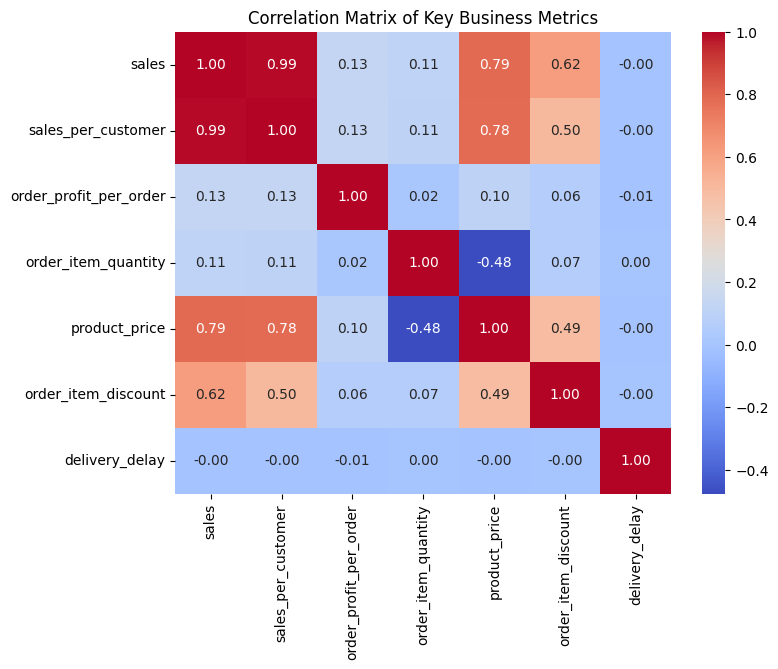

In [ ]:
# 6. Which products generate the highest revenue and are sold in the highest quantities?

corr_cols = [
    "sales",
    "sales_per_customer",
    "order_profit_per_order",
    "order_item_quantity",
    "product_price",
    "order_item_discount",
    "delivery_delay"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df_data[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Business Metrics")
plt.show()

# 2. Tokenized Logo

In [28]:
df_token.columns

Index(['Unnamed: 0', 'product', 'category', 'date', 'month', 'hour',
       'department', 'ip', 'url'],
      dtype='str')

# 1. *Univariate Analysis* 

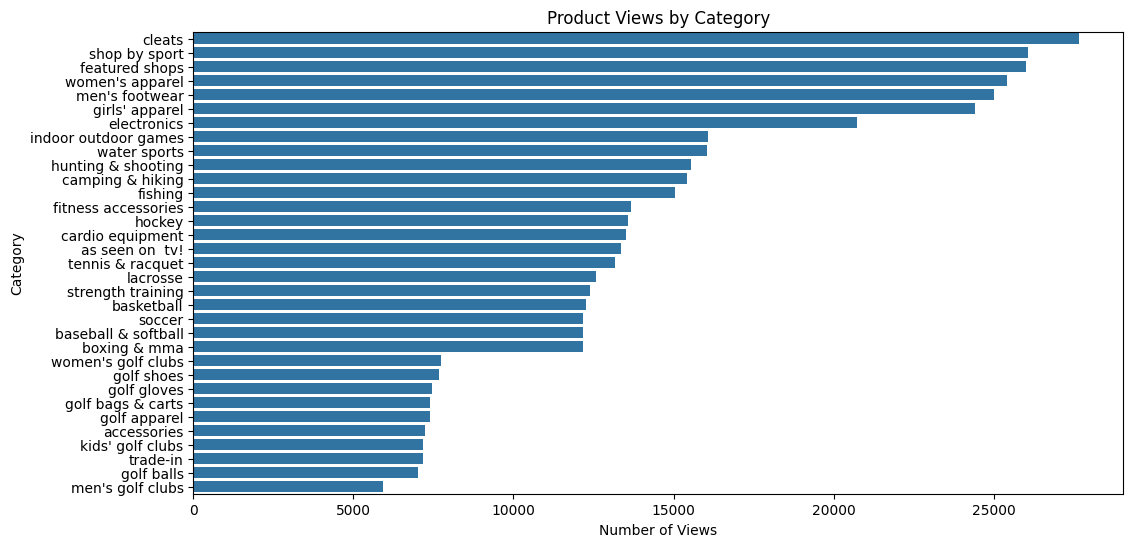

In [29]:
# 1. Which categories receive the most product views?
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_token,
    y="category",
    order=df_token["category"].value_counts().index
)

plt.title("Product Views by Category")
plt.xlabel("Number of Views")
plt.ylabel("Category")

plt.show()

In [ ]:
# Which IP addresses viewed the same product multiple times?
same_product_views = (
    df_token.groupby(["ip", "product"])
    .size()
    .reset_index(name="view_count")
    .query("view_count > 1")
    .sort_values("view_count", ascending=False)
)

same_product_views.head(20)

,ip,product,view_count
90820,73.47.232.83,Nike Men's CJ Elite 2 TD Football Cleat,51
69263,34.5.176.235,Perfect Fitness Perfect Rip Deck,47
68488,32.248.180.124,Perfect Fitness Perfect Rip Deck,47
43067,186.210.186.87,Nike Men's CJ Elite 2 TD Football Cleat,46
47829,194.234.155.155,Nike Men's CJ Elite 2 TD Football Cleat,45
11290,120.188.211.38,Perfect Fitness Perfect Rip Deck,45
81849,58.20.180.169,Nike Men's CJ Elite 2 TD Football Cleat,45
9373,116.202.25.156,Perfect Fitness Perfect Rip Deck,45
41961,183.129.35.184,Perfect Fitness Perfect Rip Deck,44
47811,194.234.155.155,Diamondback Women's Serene Classic Comfort Bi,43


# 2. Bivariate Analysis

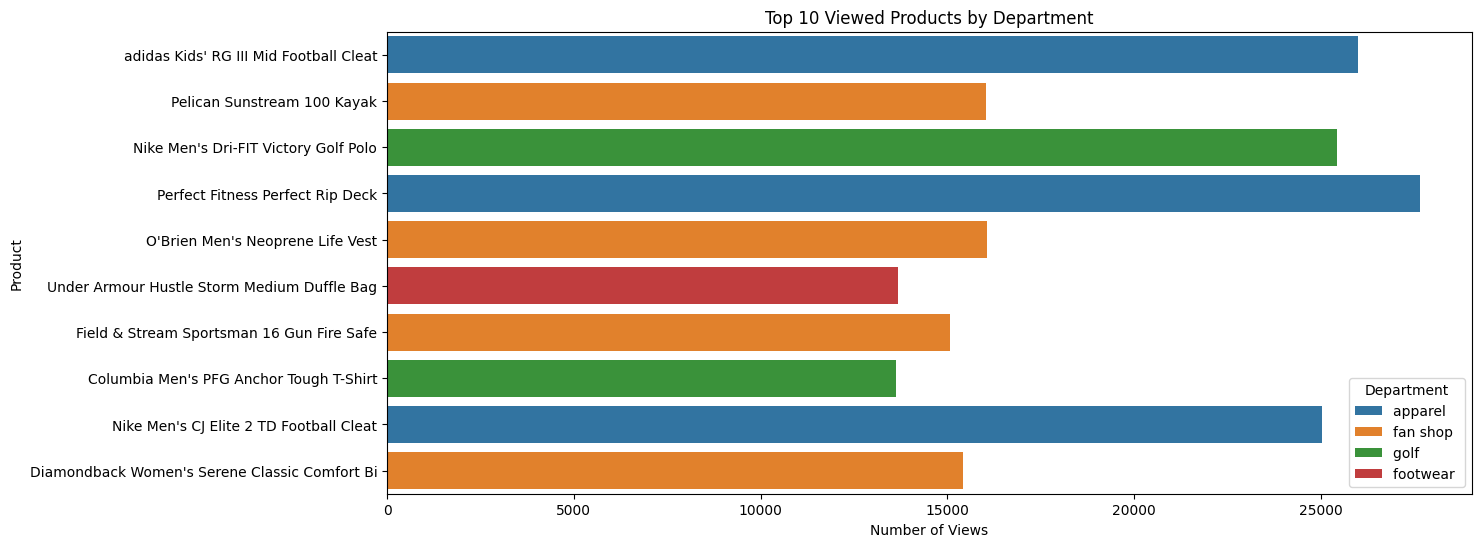

In [31]:
# 1. Which products are viewed within each department?

top_products = df_token["product"].value_counts().head(10).index

filtered_df = df_token[df_token["product"].isin(top_products)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=filtered_df,
    y="product",
    hue="department"
)

plt.title("Top 10 Viewed Products by Department")
plt.xlabel("Number of Views")
plt.ylabel("Product")
plt.legend(title="Department")

plt.show()

# 3. Multivariate Analysis

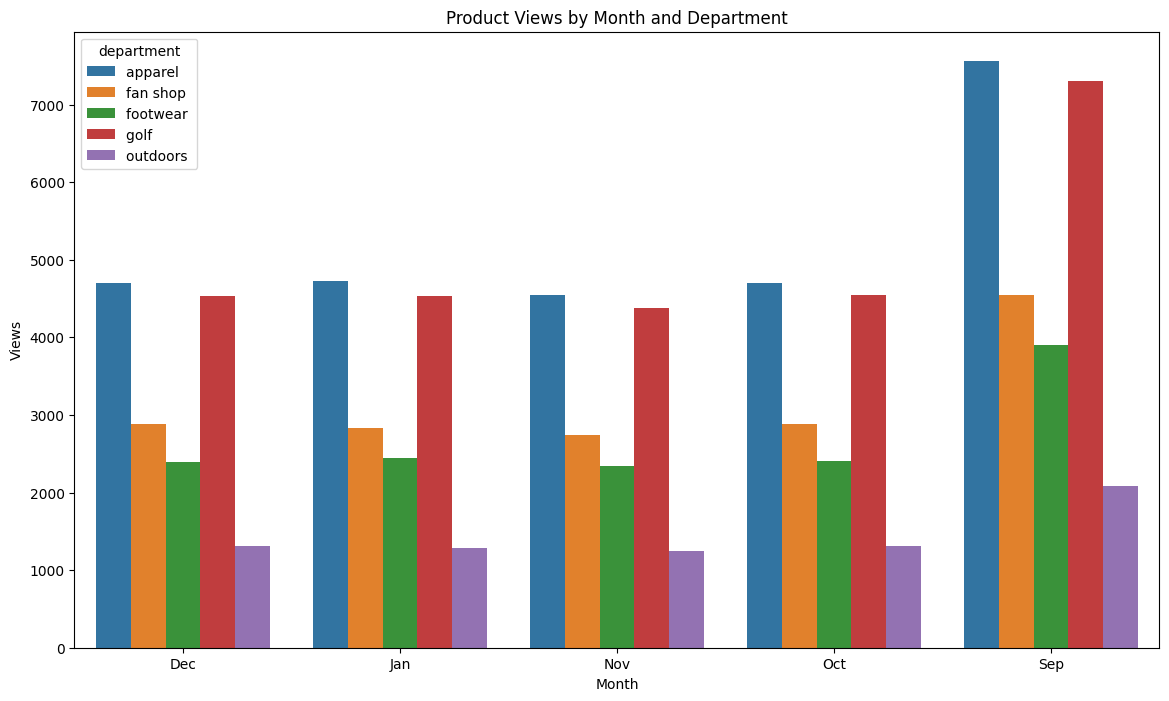

In [33]:
# 1. 
df_token.groupby(
    ["month", "department", "category"]
).size()

# Aggregate views
ma_data = (
    df_token.groupby(["month", "department", "category"])
    .size()
    .reset_index(name="views")
)

# Keep top 10 categories to avoid clutter
top_categories = (
    ma_data.groupby("category")["views"]
    .sum()
    .nlargest(10)
    .index
)

ma_data = ma_data[ma_data["category"].isin(top_categories)]

plt.figure(figsize=(14,8))

sns.barplot(
    data=ma_data,
    x="month",
    y="views",
    hue="department",
    errorbar=None
)

plt.title("Product Views by Month and Department")
plt.xlabel("Month")
plt.ylabel("Views")

plt.show()